# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** _Totaram_

**Roll Number:** _023-24-0244_

**GitHub Repository:** _https://github.com/totaramrathore/machine_learning_practical_

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")   # update path/filename if different


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**

***The Business Problem -*** The telecommunications company want to understand which customer behaviors, and services of the are associated with the customers leaving, so it can identify customers who may be at risk of churn.

***Purpose of Target Variable -*** The purpose of target variable is to use the customer demographics, services, and billing information to understand which customers are likely to leave.

**Answer 2:**

| Column            | Expected role        | Justification                                                                                            |
| ----------------- | -------------------- | -------------------------------------------------------------------------------------------------------- |
| `tenure`          | Useful predictor     | The length of the customer's relationship with the company may be associated with churn behavior.        |
| `Contract`        | Useful predictor     | Contract type may influence customer commitment and therefore may be associated with churn.              |
| `MonthlyCharges`  | Useful predictor     | Monthly charges may be related to a customer's decision to continue or leave the service.                |
| `InternetService` | Useful predictor     | Different internet-service types may be associated with different customer churn patterns.               |
| `PaymentMethod`   | Useful predictor     | Payment methods may distinguish customer groups with different churn behavior.                           |
| `customerID`      | Expected useless     | It is an identifier and does not represent a meaningful customer characteristic for predicting churn.    |
| `gender`          | Expected less useful | We initially expect gender to have limited predictive value, although this must be verified through EDA. |


**Answer 3:**

1. Are customers on different contract types associated with different churn rates?
2. Do customers with shorter or longer tenure show different churn behavior?

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [3]:
# Task 4 — dataset shape, column names, data types
df.head()
df.shape
df.dtypes
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


*Task 4:*
Total features:
21 => (20 features, 1 target variable)

*Numerical Features:*

1. SeniorCitizen
2. tenure
3. MonthlyCharges
4. TotalCharges

*categorical Features:*

1. gender
2. Partner
3. Dependents
4. PhoneService
5. MultipleLines
6. InternetService
7. OnlineSecurity
8. OnlineBackup
9. DeviceProtection
11. TechSupport
12. StreamingTV
13. StreamingMovies
14. Contract
15. PaperlessBilling
16. PaymentMethod
17. Churn

In [ ]:
# Task 5 — identify identifier columns / wrong data types
df.dtypes
df["TotalCharges"].dtype
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


*Wrong Data Type Columns:*

1. customerID: These values identify individual customers. There is no meaningful customer behavior encoded by the ID itself.
2. TotalCharges: Currently, it is an Object type. Yet the values represent amounts (Wrong data type).

In [4]:
# Task 6 — unique values in 3 categorical columns
print("1. Contract:")
print(df["Contract"].unique())

print("2. InternetService:")
print(df["InternetService"].unique())

print("3. PaymentMethod:")
print(df["PaymentMethod"].unique())


1. Contract:
['Month-to-month' 'One year' 'Two year']
2. InternetService:
['DSL' 'Fiber optic' 'No']
3. PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


**Observations (Part 2):**

Key Findings:

1. **Dataset size**: using the df.shape which provides the no.of rows and columns (samples, and features),
2. **Target**: Churn - indicates whether the customer left the company, or stayed.
3. **Different types of features**(by using the .head(), .dtypes, and .unique()):
     1. Numerical,
     2. Categorical
4. **Identifier**: *customerID* - Identifies customers but is not a meaningful predictive feature
5. **Datatype isuues**: *TotalCharges* currently, is an object, but representing numerical values (amount).


---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [5]:
# Task 7 — missing values: count and percentage per column
df.isnull().sum()
# is isnull() alone isn't enough to inspect whether there are missing
pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()

# or:
missing_total_charges = (df['TotalCharges'].astype(str).str.strip() == "").sum()
missing_percentage = (missing_total_charges / len(df)) * 100

print("Missing: ", missing_total_charges)
print(f"Missing Percentage: {missing_percentage:.2f}%")


Missing:  11
Missing Percentage: 0.16%


In [6]:
# Task 8 — duplicate rows vs duplicate IDs
print("No.of duplicate rows: ", df.duplicated().sum())
print("No.of duplicate customerIDs: ", df['customerID'].duplicated().sum())


No.of duplicate rows:  0
No.of duplicate customerIDs:  0


In [7]:
# Task 9 — investigate a suspicious / invalid value
print("'TotalCharges' feature (data type): ", df['TotalCharges'].dtype)
print("Null values when we apply .isnull(): ", df['TotalCharges'].isnull().sum())
miss_total_charg = pd.to_numeric(df['TotalCharges'], errors = "coerce").isna().sum()
print("But when we invetigate: ", miss_total_charg)
print("Effected Customers: ")
df.loc[pd.to_numeric(df["TotalCharges"], errors="coerce").isna(), ["customerID", "tenure", "TotalCharges"]]

'TotalCharges' feature (data type):  object
Null values when we apply .isnull():  0
But when we invetigate:  11
Effected Customers: 


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,
3331,7644-OMVMY,0,
3826,3213-VVOLG,0,
4380,2520-SGTTA,0,
5218,2923-ARZLG,0,
6670,4075-WKNIU,0,


**Answer 7 (which missing-value problems need action, and why):**
The missing values in ***TotalCharges*** column, caused by blank entries need action.

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
These, are the two different problems:

As, **duplicate row**, means entire row (record) comes more than once, while **duplicate IDs**, means the values of one column(feature) are duplicated.

**Answer 9 (suspicious value found and how):**
The suspicious values, found using the:

**to_numeric** function of the Pandas on the feature 'TotalCharges', caused by the blank entries.

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**
| Problem                              | Decision                      | Method Used                                       | Reason                                                                                               |
| ------------------------------------ | ----------------------------- | ------------------------------------------------- | ---------------------------------------------------------------------------------------------------- |
| `TotalCharges` is stored as `object` | Convert it to numeric         | `pd.to_numeric(..., errors='coerce')`             | `TotalCharges` represents a monetary quantity and should be numerical for analysis.                  |
| 11 blank `TotalCharges` values       | Treat them as missing values  | Convert blanks to `NaN` during numeric conversion | Blank strings do not represent valid numerical values and must be explicitly represented as missing. |
| 0 duplicate rows                     | No action                     | `df.drop_duplicates()` not required               | No complete duplicate records were found.                                                            |
| 0 duplicate customer IDs             | No action                     | No removal required                               | Every customer ID is unique in the dataset.                                                          |
| `customerID` is an identifier        | Remove from ML-ready features | `drop(columns=['customerID'])`                    | It identifies customers but does not represent a meaningful predictive characteristic.               |


In [8]:
# Task 11 — apply your cleaning decisions here

# making the copy of the original dataset for the retaining the original dataset:
clean_df = df.copy()

# removing the blank entries (blank spaces):
clean_df['TotalCharges'] = (clean_df['TotalCharges'].astype(str).str.strip())

# converting TotalCharges to the numeric:
clean_df["TotalCharges"] = pd.to_numeric(clean_df["TotalCharges"], errors="coerce")

print("Missing TotalCharges:", clean_df["TotalCharges"].isnull().sum())
print("Duplicate rows:", clean_df.duplicated().sum())

# verifying  the  results:
clean_df['TotalCharges'].dtype
clean_df['TotalCharges'].isnull().sum()
# clean_df = clean_df.dropna(subset=['TotalCharges'])
# or filling 11 rows with 0:
clean_df['TotalCharges'] = clean_df['TotalCharges'].fillna(0)
clean_df['TotalCharges'].isnull().sum()
clean_df['TotalCharges'].dtype
#
# As, we cheked about  the dubplicates: (doing again):
clean_df.duplicated().sum() # as  the sum is 0, no action required:
clean_df['customerID'].duplicated().sum() # Here, sum is 0:
#
# now, removing the customerID feature - identifier:
clean_df = clean_df.drop(columns=['customerID'])
#
# Now verifying the results:
clean_df.info()
#
print("=> Missing values: ")
print(clean_df.isnull().sum())
#
print("=> Duplicate Rows:")
print(clean_df.duplicated().sum())

Missing TotalCharges: 11
Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16 

In [ ]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)


---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

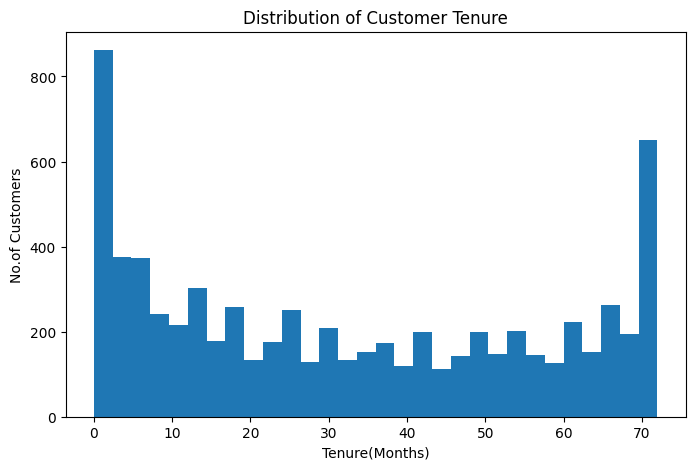

In [9]:
# Task 12 — numerical feature 1: distribution plot
plt.figure(figsize = (8, 5))
plt.hist(clean_df['tenure'], bins=30)
plt.xlabel("Tenure(Months)")
plt.ylabel("No.of Customers")
plt.title("Distribution of Customer Tenure")
plt.show()

**Observation:** _(what did you learn from this chart?)_

Customer tenure covers a wide range from new customers to customers who have stayed for several years. The distribution is somewhat uneven, with customers concentrated at different tenure levels rather than being uniformly distributed.

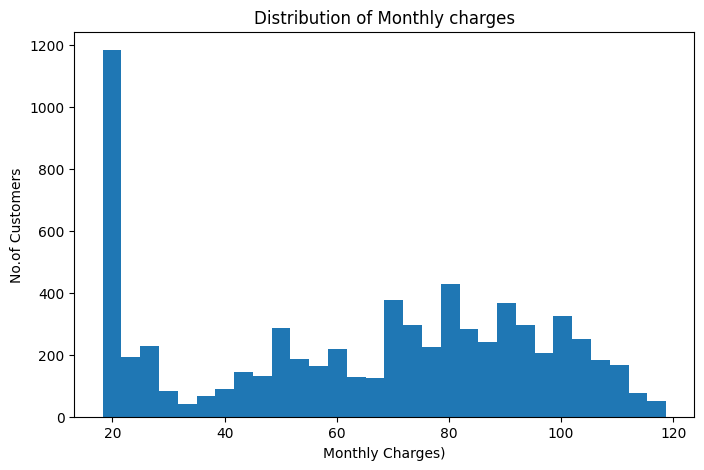

In [10]:
# Task 12 — numerical feature 2: distribution plot
# Task 12 — numerical feature 1: distribution plot
plt.figure(figsize = (8, 5))
plt.hist(clean_df['MonthlyCharges'], bins=30)
plt.xlabel("Monthly Charges)")
plt.ylabel("No.of Customers")
plt.title("Distribution of Monthly charges")
plt.show()


**Observation:** _(what did you learn from this chart?)_

Monthly charges vary substantially among customers, reflecting differences in subscribed services and plans. The distribution is slightly left-skewed, but values are spread across a broad range.

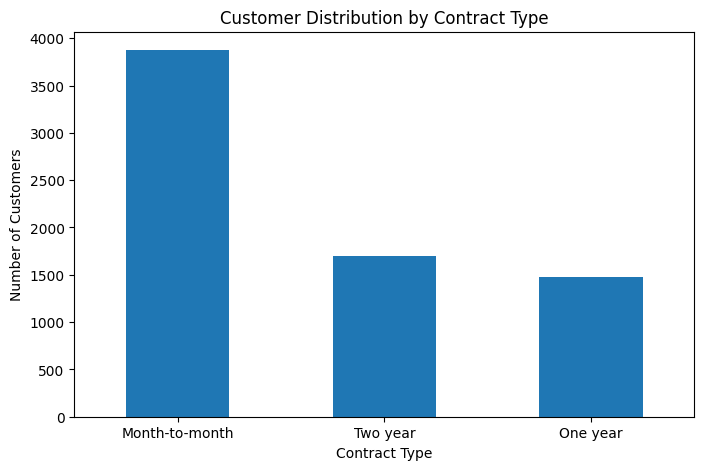

In [11]:
# Task 12 — categorical feature 1: distribution plot
plt.figure(figsize=(8, 5))
clean_df["Contract"].value_counts().plot(kind="bar")

plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Contract Type")
plt.xticks(rotation=0)

plt.show()


**Observation:** _(what did you learn from this chart?)_

Month-to-month customers form the largest group with 3,875 customers, followed by two-year contracts with 1,695 and one-year contracts with 1,473. Therefore, the dataset is not evenly distributed across contract types.

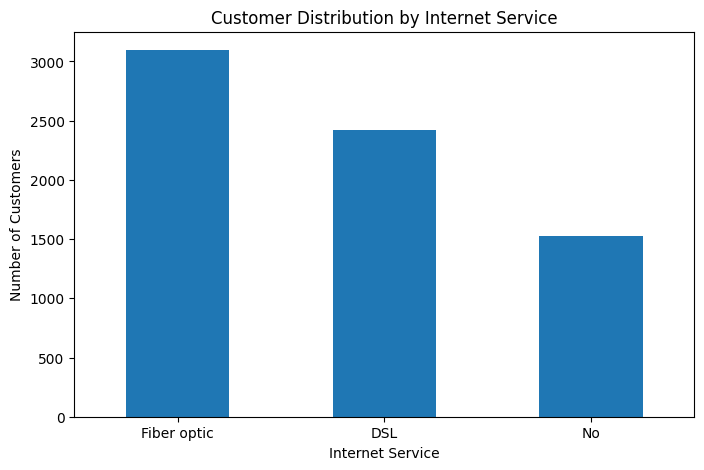

In [12]:
# Task 12 — categorical feature 2: distribution plot
plt.figure(figsize=(8, 5))
clean_df["InternetService"].value_counts().plot(kind="bar")

plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Internet Service")
plt.xticks(rotation=0)

plt.show()


In [13]:
# Task 13:
print("tenure skewness:", clean_df["tenure"].skew())
print("MonthlyCharges skewness:", clean_df["MonthlyCharges"].skew())
print("TotalCharges skewness:", clean_df["TotalCharges"].skew())

tenure skewness: 0.2395397495619829
MonthlyCharges skewness: -0.22052443394398033
TotalCharges skewness: 0.963234654832277


**Observation:** _(what did you learn from this chart?)_

Fiber optic is the largest internet-service group with 3,096 customers, followed by DSL with 2,421, while 1,526 customers have no internet service. This indicates that the dataset contains substantially different customer service groups.

**Answer 13 (outliers / skew and possible explanation):**
_(your answer here)_

TotalCharges shows the strongest skewness, with a right-skewed distribution. This is reasonable because customers have different lengths of service, so long-term customers can accumulate substantially larger total charges. tenure and MonthlyCharges show only mild skewness, and the IQR-based check does not identify statistical outliers.

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [14]:
# Task 14 — churn counts and percentages
churn_counts = clean_df["Churn"].value_counts()
churn_percentages = clean_df["Churn"].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_percentages)


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


**Answer 14 (balanced or imbalanced?):**
_(your answer here)_

No. The target is imbalanced.

**Answer 15 (why imbalance might matter later):**
_(your answer here)_

Class imbalance matters because a model may encounter many more examples of one class than the other during training. As a result, overall accuracy can give an incomplete picture of performance if the model performs well on the majority class but poorly on the minority churn class.

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

In [15]:
# Task 16 — categorical feature 1 vs Churn
contract_churn = pd.crosstab(
    clean_df["Contract"],
    clean_df["Churn"],
    normalize="index"
) * 100

print(contract_churn)


Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


**Observation:** Month-to-month customers have a much higher churn rate than customers with one-year or two-year contracts.

**Evidence:** The churn rate is 42.71% for month-to-month customers, compared with 11.27% for one-year and 2.83% for two-year contracts.

**Possible Explanation:** Longer contracts may represent stronger customer commitment or make switching providers less immediate, while month-to-month customers have greater flexibility to leave.

In [16]:
# Task 16 — categorical feature 2 vs Churn
internet_churn = pd.crosstab(
    clean_df["InternetService"],
    clean_df["Churn"],
    normalize="index"
) * 100

print(internet_churn)


Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


**Observation:** Fiber-optic customers have a considerably higher observed churn rate than DSL customers and customers without internet service.

**Evidence:** The churn rate is 41.89% for fiber-optic customers, compared with 18.96% for DSL and 7.40% for customers without internet service.

**Possible Explanation:** Fiber-optic customers may differ in pricing, service expectations, or other characteristics associated with churn. The analysis shows an association, but it does not prove that fiber optic service itself causes churn.

In [18]:
# Task 17 — numerical feature 1 vs Churn
clean_df.groupby("Churn")["MonthlyCharges"].agg(
    ["mean", "median", "min", "max"]
)


,mean,median,min,max
Churn,,,,
No,61.265124,64.425,18.25,118.75
Yes,74.441332,79.650,18.85,118.35


**Observation:** Customers who churned generally have higher monthly charges than customers who stayed.

**Evidence:** The average monthly charge is approximately 74.44 for churned customers compared with 61.27 for non-churned customers.

**Possible Explanation:** Higher monthly charges may be associated with particular service combinations or customer segments that have higher churn rates. Again, this is an observed association, not proof of causation.

In [17]:
# Task 17 — numerical feature 2 vs Churn
clean_df.groupby("Churn")["tenure"].agg(
    ["mean", "median", "min", "max"]
)


,mean,median,min,max
Churn,,,,
No,37.569965,38.0,0,72
Yes,17.979133,10.0,1,72


**Observation:** Customers who churned generally have substantially shorter tenure than customers who remained.

**Evidence:** The mean tenure is approximately 17.98 months for churned customers versus 37.57 months for non-churned customers. The median is 10 months versus 38 months.

**Possible Explanation:** Newer customers may have had less time to establish loyalty or may be more willing to switch providers.

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

In [19]:
# Task 18 — correlation matrix and heatmap
numeric_cols = clean_df.select_dtypes(
    include=np.number
).columns

corr_matrix = clean_df[numeric_cols].corr()

print(corr_matrix.round(3))


                SeniorCitizen  tenure  MonthlyCharges  TotalCharges
SeniorCitizen           1.000   0.017           0.220         0.103
tenure                  0.017   1.000           0.248         0.826
MonthlyCharges          0.220   0.248           1.000         0.651
TotalCharges            0.103   0.826           0.651         1.000


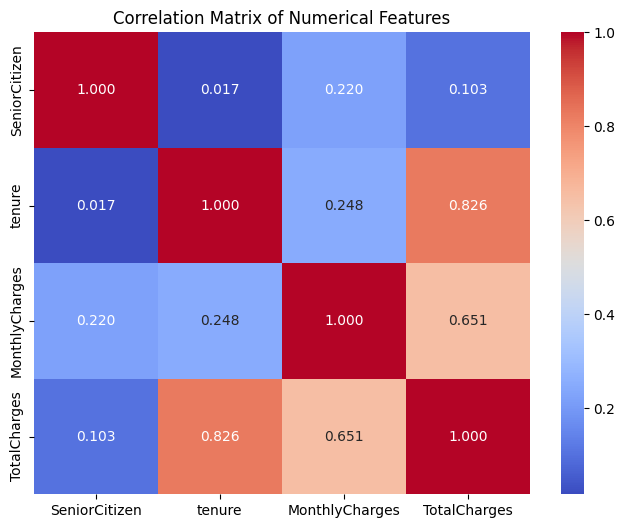

In [20]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

**Answer 18 (most correlated pairs):**
_(your answer here)_

Strongest pair:
tenure and TotalCharges, with correlation ≈ 0.826.
This is a strong positive relationship.

**Answer 19 (correlation vs. causation; potential problems):**
_(your answer here)_

No. Correlation indicates that two variables are associated, but it does not establish that one variable causes the other. The strong relationship between tenure and TotalCharges is expected because customers who remain longer have more time to accumulate total charges, but the two variables may provide overlapping information to a future model.

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
_(your answer here)_

The main suspect is:

customerID

It is an identifier rather than a meaningful customer characteristic.
It should therefore not be used as an ML feature.
The manual explicitly asks us to inspect for columns that would only be known after churn or that are purely identifiers.
For this dataset, we do not identify a clear feature that is inherently a post-churn outcome.
TotalCharges, for example, is available as accumulated customer billing information and is not automatically a leakage variable merely because it is strongly related to tenure.

**Answer 21 (what would go wrong):**
_(your answer here)_

If a post-churn variable were included in the model, the model could use information that would not actually be available when making a real prediction. This would make evaluation results artificially optimistic and could cause the model to perform much worse in a real-world deployment.

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column             | Type             | Role    | Action | Reason                                                                     |
| ------------------ | ---------------- | ------- | ------ | -------------------------------------------------------------------------- |
| `customerID`       | Identifier       | —       | Remove | Identifies customers but is not a meaningful predictive feature.           |
| `gender`           | Categorical      | Feature | Keep   | Customer characteristic that can be investigated as a potential predictor. |
| `SeniorCitizen`    | Numerical/Binary | Feature | Keep   | Represents senior-citizen status.                                          |
| `Partner`          | Categorical      | Feature | Keep   | Customer demographic characteristic.                                       |
| `Dependents`       | Categorical      | Feature | Keep   | Customer demographic characteristic.                                       |
| `tenure`           | Numerical        | Feature | Keep   | Represents length of customer relationship.                                |
| `PhoneService`     | Categorical      | Feature | Keep   | Represents subscribed phone service.                                       |
| `MultipleLines`    | Categorical      | Feature | Keep   | Represents customer's phone-line configuration.                            |
| `InternetService`  | Categorical      | Feature | Keep   | Represents internet service type.                                          |
| `OnlineSecurity`   | Categorical      | Feature | Keep   | Represents subscribed security service.                                    |
| `OnlineBackup`     | Categorical      | Feature | Keep   | Represents backup service.                                                 |
| `DeviceProtection` | Categorical      | Feature | Keep   | Represents device-protection service.                                      |
| `TechSupport`      | Categorical      | Feature | Keep   | Represents technical-support service.                                      |
| `StreamingTV`      | Categorical      | Feature | Keep   | Represents streaming-TV service.                                           |
| `StreamingMovies`  | Categorical      | Feature | Keep   | Represents streaming-movie service.                                        |
| `Contract`         | Categorical      | Feature | Keep   | Strongly associated with observed churn differences.                       |
| `PaperlessBilling` | Categorical      | Feature | Keep   | Represents billing preference.                                             |
| `PaymentMethod`    | Categorical      | Feature | Keep   | Shows different observed churn patterns.                                   |
| `MonthlyCharges`   | Numerical        | Feature | Keep   | Represents current monthly billing amount.                                 |
| `TotalCharges`     | Numerical        | Feature | Keep   | Converted to numeric and missing values handled.                           |
| `Churn`            | Categorical      | Target  | Keep   | This is the variable the future classifier will predict.                   |


---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [ ]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# ... apply your cleaning steps here ...

# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)


In [22]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
clean_df.info()

print("Missing values:")
print(clean_df.isnull().sum())

print("\nTotal missing values:",
      clean_df.isnull().sum().sum())

print("\nTotal rows:", len(clean_df))
print("Total columns:", len(clean_df.columns))

print("\nTotalCharges dtype:",
      clean_df["TotalCharges"].dtype)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: The dataset contains substantially more customers who did not churn than customers who churned.
- Evidence: 5,174 customers (73.46%) did not churn, while 1,869 customers (26.54%) churned.
- Interpretation: The target variable is imbalanced, so future ML models should not be evaluated using accuracy alone.

**Finding 2**
- Observation: Contract type is strongly associated with customer churn.
- Evidence: The churn rate is 42.71% for month-to-month contracts, 11.27% for one-year contracts, and 2.83% for two-year contracts.
- Interpretation: Customers with month-to-month contracts are much more likely to churn than customers with longer-term contracts.

**Finding 3**
- Observation: Customers who churned generally had shorter tenure than customers who stayed.
- Evidence: The mean tenure was 17.98 months for churned customers compared with 37.57 months for customers who did not churn.
- Interpretation: Newer customers appear to have a higher likelihood of churn, while longer customer relationships are associated with lower observed churn.

**Finding 4**
- Observation: Internet service type shows noticeable differences in churn rates.
- Evidence: Fiber-optic customers had a churn rate of 41.89%, compared with 18.96% for DSL customers and 7.40% for customers without internet service.
- Interpretation: Internet service type is associated with customer churn, although this relationship does not by itself prove that the service type causes churn.

**Finding 5**
- Observation: `tenure` and `TotalCharges` have a strong positive relationship.
- Evidence: Their correlation coefficient is approximately 0.826.
- Interpretation: Customers with longer tenure generally accumulate higher total charges. These features therefore contain related information that should be considered when developing the ML model.

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?

The most important data-quality issue was the 11 blank values in the `TotalCharges` column. Although they were not initially detected as missing values, converting the column to numeric revealed them as missing values. They were handled by treating them as 0 because the corresponding customers had a tenure of 0 months.

2. What was the most interesting pattern you discovered?

The most interesting pattern was the strong difference in churn rates across contract types. Month-to-month customers had a much higher churn rate than customers with one-year or two-year contracts.

3. Which feature seems most useful for predicting churn?

`Contract` seems particularly useful for predicting churn because its categories show substantial differences in observed churn rates. `tenure` and `InternetService` also show noticeable relationships with churn.

4. Which feature should probably not be used, and why?

`customerID` should probably not be used because it is only an identifier. It identifies individual customers but does not provide meaningful information about their behavior or services for predicting churn.

5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?

The categorical features will need to be encoded into numerical representations suitable for the selected ML algorithm. Numerical features may require scaling depending on the model, and the target variable will need to be prepared for binary classification. The data should also be divided into training and testing sets while avoiding data leakage.

6. What would you do next if you had another 3 hours?

I would investigate the strongest churn-related patterns in more detail, particularly contract type, tenure, monthly charges, internet service, and payment method. I would also examine combinations of these features and prepare a clear preprocessing plan for the ML modeling stage.

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.